<a href="https://colab.research.google.com/github/fernandodeeke/Hydraulics/blob/main/turbulent_2_tank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculated Parameters:
  Connecting Pipe Resistance  R₁₂ = 10255.01 s/m²
  Turbulent Valve Coefficient k₂  = 0.000041 m²⋅√ m / s

Analytical Steady-State Heights:
  h₁* = 33.47 cm
  h₂* = 16.38 cm



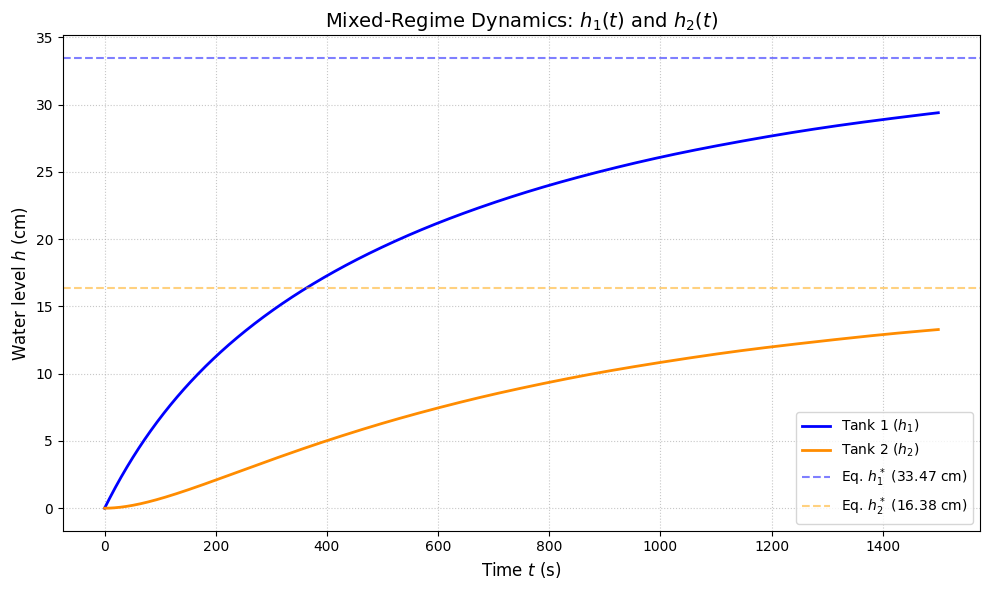

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. System Parameters (Tabletop Lab Scale)
# ==========================================
# Tank Geometry: 0.02 m^2 corresponds to ~16 cm diameter cylinders
A1 = 0.02        # Area of Tank 1 (m^2)
A2 = 0.02        # Area of Tank 2 (m^2)
q1 = 1.667e-5    # Constant inflow (1 L/min converted to m^3/s)

# Fluid Properties (Water at 20 C)
mu = 1.0e-3      # Dynamic viscosity (Pa*s)
rho = 1000.0     # Density (kg/m^3)
g = 9.81         # Gravity (m/s^2)

# Laminar Connecting Pipe Dimensions
L = 0.2          # Pipe length (20 cm)
r = 0.0015       # Pipe radius (1.5 mm, standard 3mm ID tubing)

# Turbulent Outflow Valve Parameters
Cd = 0.62        # Discharge coefficient (typical for sharp-edged orifice)
a = 1.5e-5       # Valve opening area (0.15 cm^2)

# ==========================================
# 2. Derived Physical Coefficients
# ==========================================
# Calculate laminar resistance using the Hagen-Poiseuille law
R12 = (8 * mu * L) / (rho * g * np.pi * r**4)

# Calculate the lumped turbulent valve coefficient
k2 = Cd * a * np.sqrt(2 * g)

print(f"Calculated Parameters:")
print(f"  Connecting Pipe Resistance  R\u2081\u2082 = {R12:.2f} s/m\u00b2")
print(f"  Turbulent Valve Coefficient k\u2082  = {k2:.6f} m\u00b2\u22c5\u221a m / s\n")

# ==========================================
# 3. Steady-State (Equilibrium) Calculation
# ==========================================
h2_star = (q1 / k2)**2
h1_star = R12 * q1 + h2_star

# Print in centimeters for better physical intuition
print(f"Analytical Steady-State Heights:")
print(f"  h\u2081* = {h1_star * 100:.2f} cm")
print(f"  h\u2082* = {h2_star * 100:.2f} cm\n")

# ==========================================
# 4. Differential Equations Definition
# ==========================================
def semilinear_tanks(t, h):
    # Computes dh1/dt and dh2/dt using the derived physical coefficients.

    h1, h2 = h

    # Failsafe: prevent numerical solver from evaluating sqrt(negative)
    h1 = max(0, h1)
    h2 = max(0, h2)

    # Flow models
    q12 = (h1 - h2) / R12    # Laminar flow (linear in delta-h)
    q2  = k2 * np.sqrt(h2)   # Turbulent flow (nonlinear in h2)

    # Mass balance
    dh1_dt = (q1  - q12) / A1
    dh2_dt = (q12 - q2)  / A2

    return [dh1_dt, dh2_dt]

# ==========================================
# 5. Numerical Integration
# ==========================================
# Simulate for 1500 seconds (25 minutes)
t_span = (0, 1500)
t_eval = np.linspace(0, 1500, 1000)
initial_conditions = [0.0, 0.0]

# Solve using Runge-Kutta 45
solution = solve_ivp(semilinear_tanks, t_span, initial_conditions, t_eval=t_eval)

# ==========================================
# 6. Plotting the Dynamics
# ==========================================
plt.figure(figsize=(10, 6))

# Plot transient responses (converting meters to centimeters for the y-axis)
plt.plot(solution.t, solution.y[0] * 100, 'b-', lw=2, label=r'Tank 1 ($h_1$)')
plt.plot(solution.t, solution.y[1] * 100, 'darkorange', lw=2, label=r'Tank 2 ($h_2$)')

# Plot analytical steady-state
plt.axhline(h1_star * 100, color='blue', linestyle='--', alpha=0.5,
            label=f'Eq. $h_1^*$ ({h1_star * 100:.2f} cm)')
plt.axhline(h2_star * 100, color='orange', linestyle='--', alpha=0.5,
            label=f'Eq. $h_2^*$ ({h2_star * 100:.2f} cm)')

# Axis labels and title
plt.title(r'Mixed-Regime Dynamics: $h_1(t)$ and $h_2(t)$', fontsize=14)
plt.xlabel(r'Time $t$ (s)', fontsize=12)
plt.ylabel(r'Water level $h$ (cm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()
